# 02 — Feature Engineering et Préparation ML

**AssuML** — Préparation du dataset pour l'entraînement des modèles ML.

Ce notebook transforme les données brutes (`insurance.csv`) en un dataset prêt à l'emploi pour la modélisation :
- Renommage des colonnes (nommage métier français)
- Encodage des variables catégorielles
- Création de la variable cible classification (`categorie_risque`)
- Split train/test stratifié
- Export vers `data/processed/features.csv`


## 1. Imports et configuration

Chargement des librairies et résolution du chemin racine du projet (`PROJECT_ROOT`). Les modules métier `cleaning` et `normalization` sont importés depuis le pipeline de données.


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(),
                               '..' if os.path.basename(os.getcwd()) == 'notebooks' else '.'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from data_pipeline.transform.cleaning import rename_columns
from data_pipeline.transform.normalization import encode_categoricals

print(f'Racine projet : {PROJECT_ROOT}')
print('Imports OK')


Racine projet : /Users/leogallus/Projets/AssuML
Imports OK


## 2. Chargement du dataset

Lecture du fichier `insurance.csv` (1 338 lignes × 7 colonnes). Le chemin est relatif au répertoire de travail courant. Une assertion bloquante vérifie la forme du dataset au chargement.


In [2]:
CSV_PATH = os.path.join(PROJECT_ROOT, 'data', 'small_data', 'insurance.csv')
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f'Dataset introuvable : {CSV_PATH}')

df = pd.read_csv(CSV_PATH)
print(f'Dataset chargé : {df.shape}')
assert df.shape == (1338, 7), f'Shape inattendu : {df.shape}'
df.head()


Dataset chargé : (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 3. Renommage des colonnes — Nommage métier français

Application du mapping défini dans la constitution AssuML §2 via `cleaning.rename_columns` :

| Colonne originale (Kaggle) | Colonne renommée |
|---|---|
| `sex` | `sexe` |
| `bmi` | `imc` |
| `children` | `enfants` |
| `smoker` | `fumeur` |


In [3]:
df = rename_columns(df)
print('Colonnes après renommage :', df.columns.tolist())
assert 'sexe' in df.columns and 'imc' in df.columns
df.head()


Colonnes après renommage : ['age', 'sexe', 'imc', 'enfants', 'fumeur', 'region', 'charges']


,age,sexe,imc,enfants,fumeur,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 4. Encodage des variables catégorielles

Application de `normalization.encode_categoricals` :
- **`sexe`** : `female` → 1, `male` → 0
- **`fumeur`** : `yes` → 1, `no` → 0
- **`region`** : encodage one-hot avec `drop_first=True` → `northeast` supprimé comme catégorie de référence pour éviter la multicolinéarité


In [4]:
df = encode_categoricals(df)
print('Colonnes après encodage :', df.columns.tolist())
print('\nTypes :')
print(df.dtypes)
assert df['sexe'].isin([0,1]).all()
assert df['fumeur'].isin([0,1]).all()
assert 'region_northeast' not in df.columns
df.head()


Colonnes après encodage : ['age', 'sexe', 'imc', 'enfants', 'fumeur', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']

Types :
age                   int64
sexe                  int64
imc                 float64
enfants               int64
fumeur                int64
charges             float64
region_northwest      int64
region_southeast      int64
region_southwest      int64
dtype: object


,age,sexe,imc,enfants,fumeur,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,0,0,1
1,18,0,33.770,1,0,1725.55230,0,1,0
2,28,0,33.000,3,0,4449.46200,0,1,0
3,33,0,22.705,0,0,21984.47061,1,0,0
4,32,0,28.880,0,0,3866.85520,1,0,0


## 5. Création de la variable cible classification — `categorie_risque`

Discrétisation de la variable continue `charges` en 4 catégories de risque assurantiel (seuils définis dans la constitution AssuML) :

| Catégorie | Seuil de charges |
|---|---|
| `faible` | < 5 000 USD |
| `moyen` | 5 000 – 15 000 USD |
| `eleve` | 15 000 – 30 000 USD |
| `critique` | ≥ 30 000 USD (~7% du dataset) |

⚠️ La classe `critique` est fortement minoritaire → un split **stratifié** est indispensable.


In [5]:
df['categorie_risque'] = pd.cut(
    df['charges'],
    bins=[0, 5000, 15000, 30000, float('inf')],
    labels=['faible', 'moyen', 'eleve', 'critique'],
    right=False
)

print('Distribution des catégories de risque :')
print(df['categorie_risque'].value_counts())
print('\nProportions :')
print(df['categorie_risque'].value_counts(normalize=True).round(3))
assert df['categorie_risque'].isnull().sum() == 0
assert set(df['categorie_risque'].unique()) == {'faible','moyen','eleve','critique'}


Distribution des catégories de risque :
categorie_risque
moyen       621
faible      359
eleve       196
critique    162
Name: count, dtype: int64

Proportions :
categorie_risque
moyen       0.464
faible      0.268
eleve       0.146
critique    0.121
Name: proportion, dtype: float64


### Visualisation de la distribution des catégories de risque

Barplot avec effectifs et pourcentages annotés + camembert des proportions. Met en évidence le déséquilibre entre les classes.


/var/folders/sd/_747tl1942g3lfv8k11wjtxc0000gn/T/ipykernel_10082/241987159.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x=counts.index, y=counts.values, palette='RdYlGn_r', ax=axes[0])


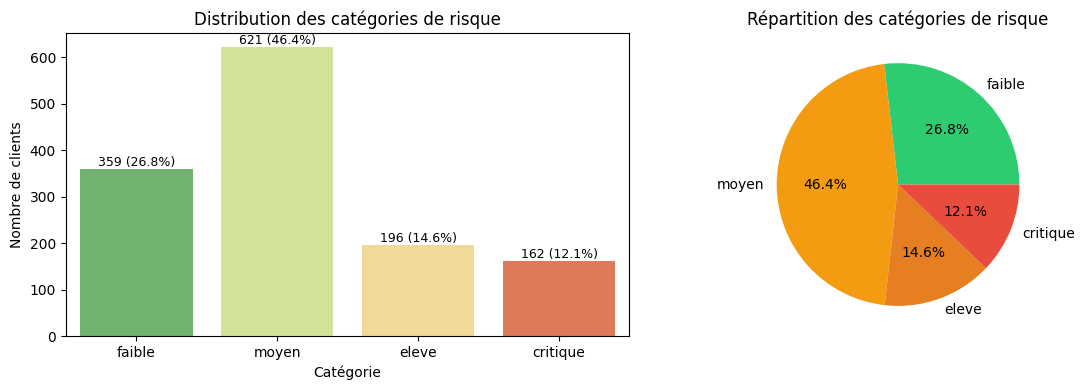


⚠️  Déséquilibre des classes : critique ~7% — stratify requis sur le split


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ordre = ['faible', 'moyen', 'eleve', 'critique']
counts = df['categorie_risque'].value_counts().reindex(ordre)
sb.barplot(x=counts.index, y=counts.values, palette='RdYlGn_r', ax=axes[0])
axes[0].set_title('Distribution des catégories de risque')
axes[0].set_xlabel('Catégorie')
axes[0].set_ylabel('Nombre de clients')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())} ({int(p.get_height())/1338*100:.1f}%)',
                     (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)
proportions = df['categorie_risque'].value_counts(normalize=True).reindex(ordre)
axes[1].pie(proportions, labels=ordre, autopct='%1.1f%%',
            colors=['#2ecc71', '#f39c12', '#e67e22', '#e74c3c'])
axes[1].set_title('Répartition des catégories de risque')
plt.tight_layout()
plt.show()

print('\n⚠️  Déséquilibre des classes : critique ~7% — stratify requis sur le split')


## 6. Séparation features (X) et variables cibles (y)

- **X** : les 8 variables explicatives retenues (age, sexe, imc, enfants, fumeur + 3 colonnes region encodées)
- **y_reg** : variable cible pour la **régression** (montant des charges en USD)
- **y_clf** : variable cible pour la **classification** (catégorie de risque)


In [7]:
FEATURE_COLS = ['age','sexe','imc','enfants','fumeur',
               'region_northwest','region_southeast','region_southwest']

X = df[FEATURE_COLS]
y_reg = df['charges']
y_clf = df['categorie_risque']

print(f'X shape : {X.shape}')
print(f'y_reg shape : {y_reg.shape}')
print(f'y_clf shape : {y_clf.shape}')
print('\nTypes des features :')
X.dtypes


X shape : (1338, 8)
y_reg shape : (1338,)
y_clf shape : (1338,)

Types des features :


age                   int64
sexe                  int64
imc                 float64
enfants               int64
fumeur                int64
region_northwest      int64
region_southeast      int64
region_southwest      int64
dtype: object

## 7. Split train / test stratifié (80% / 20%)

Division du dataset avec :
- `test_size=0.2` → 80% entraînement, 20% test
- `random_state=42` → reproductibilité des résultats
- `stratify=y_clf` → **indispensable** pour préserver la proportion des classes rares (`critique` ~7%) dans les deux sous-ensembles


In [8]:
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42, stratify=y_clf
)
_, _, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f'X_train : {X_train.shape} ({X_train.shape[0]/1338*100:.1f}%)')
print(f'X_test  : {X_test.shape}  ({X_test.shape[0]/1338*100:.1f}%)')
assert X_train.shape[0] + X_test.shape[0] == 1338
print('\nVérification stratification :')
print('Train :', y_train_clf.value_counts(normalize=True).round(3).to_dict())
print('Test  :', y_test_clf.value_counts(normalize=True).round(3).to_dict())


X_train : (1070, 8) (80.0%)
X_test  : (268, 8)  (20.0%)

Vérification stratification :
Train : {'moyen': 0.464, 'faible': 0.268, 'eleve': 0.147, 'critique': 0.121}
Test  : {'moyen': 0.463, 'faible': 0.269, 'eleve': 0.146, 'critique': 0.123}


## 8. Sauvegarde dans `data/processed/features.csv`

Export du dataset préparé (features + les deux variables cibles) vers `data/processed/features.csv`. Ce fichier sera utilisé directement par les scripts d'entraînement des modèles ML.

Structure du fichier exporté : **1 338 lignes × 10 colonnes** (8 features + `charges` + `categorie_risque`).


In [9]:
output_path = os.path.join(PROJECT_ROOT, 'data', 'processed', 'features.csv')
os.makedirs(os.path.dirname(output_path), exist_ok=True)

df_save = X.copy()
df_save['charges'] = y_reg
df_save['categorie_risque'] = y_clf

df_save.to_csv(output_path, index=False)

print(f'features.csv sauvegardé : {df_save.shape[0]} lignes, {df_save.shape[1]} colonnes')
print(f'Chemin : {output_path}')
print('Aperçu :')
df_save.head()


features.csv sauvegardé : 1338 lignes, 10 colonnes
Chemin : /Users/leogallus/Projets/AssuML/data/processed/features.csv
Aperçu :


,age,sexe,imc,enfants,fumeur,region_northwest,region_southeast,region_southwest,charges,categorie_risque
0,19,1,27.900,0,1,0,0,1,16884.92400,eleve
1,18,0,33.770,1,0,0,1,0,1725.55230,faible
2,28,0,33.000,3,0,0,1,0,4449.46200,faible
3,33,0,22.705,0,0,1,0,0,21984.47061,eleve
4,32,0,28.880,0,0,1,0,0,3866.85520,faible


## 9. Validation finale

Relecture du fichier `features.csv` et vérifications par assertions :
- Shape exacte : 1 338 × 10
- Colonne `categorie_risque` présente
- Exactement 4 catégories distinctes
- Aucune valeur manquante


In [10]:
output_path = os.path.join(PROJECT_ROOT, 'data', 'processed', 'features.csv')
features = pd.read_csv(output_path)

assert features.shape == (1338, 10), f'Shape inattendu : {features.shape}'
assert 'categorie_risque' in features.columns
assert features['categorie_risque'].nunique() == 4
assert features.isnull().sum().sum() == 0

print('✅ Toutes les assertions passent')
print(f'Shape : {features.shape}')
print(f'Colonnes : {list(features.columns)}')
print('\nDistribution categorie_risque :')
print(features['categorie_risque'].value_counts())


✅ Toutes les assertions passent
Shape : (1338, 10)
Colonnes : ['age', 'sexe', 'imc', 'enfants', 'fumeur', 'region_northwest', 'region_southeast', 'region_southwest', 'charges', 'categorie_risque']

Distribution categorie_risque :
categorie_risque
moyen       621
faible      359
eleve       196
critique    162
Name: count, dtype: int64


---
## Récapitulatif

| Artefact | Chemin | Contenu |
|----------|--------|---------|
| Dataset préparé |  | 1 338 lignes, 10 colonnes |
| X_train | En mémoire | ~1 070 lignes, 8 features |
| X_test | En mémoire | ~268 lignes, 8 features |
| y_train_reg | En mémoire | charges (régression) |
| y_train_clf | En mémoire | categorie_risque (classification) |

**Prochaine étape** :  — entraînement des modèles ML